##Project Name
### **Phishing Website Detection using Decision Tree**

##Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

##Load Dataset

In [2]:
train_data = pd.read_csv(
    'https://new-assets.ccbp.in/frontend/content/aiml/classical-ml/Training_Dataset.csv')

test_data = pd.read_csv(
    'https://new-assets.ccbp.in/frontend/content/aiml/classical-ml/Training_Test_Data.csv')


## Column Explanations

1. **having_IP_Address**: Indicates if the URL contains an IP address instead of a domain name.
   - **-1**: Contains an IP address (highly suspicious).
   - **1**: Does not contain an IP address (legitimate).

2. **URL_Length**: Measures the length of the URL.
   - **-1**: Long URL (phishing likely).
   - **0**: Moderately long URL (suspicious).
   - **1**: Short URL (legitimate).

3. **Shortining_Service**: Checks if the URL uses a shortening service.
   - **-1**: Uses a shortening service (phishing likely).
   - **1**: Does not use shortening service (legitimate).

4. **having_At_Symbol**: Determines if the "@" symbol is present in the URL.
   - **-1**: Contains "@" symbol (phishing likely).
   - **1**: Does not contain "@" symbol (legitimate).

5. **double_slash_redirecting**: Verifies improper usage of "//" in the URL.
   - **-1**: Suspicious placement of "//" (phishing likely).
   - **1**: Normal placement of "//" (legitimate).

6. **Prefix_Suffix**: Checks for hyphens in domain names.
   - **-1**: Contains prefix/suffix with "-" (phishing likely).
   - **1**: Does not contain prefix/suffix (legitimate).

7. **having_Sub_Domain**: Measures the number of subdomains.
   - **-1**: More than two subdomains (phishing likely).
   - **0**: One subdomain (suspicious).
   - **1**: No subdomains (legitimate).

8. **SSLfinal_State**: Examines SSL certificate status.
   - **-1**: No SSL certificate or invalid SSL (phishing likely).
   - **0**: Valid but less trustworthy SSL (suspicious).
   - **1**: Valid and trusted SSL certificate (legitimate).

9. **Domain_registeration_length**: Evaluates the registration period of the domain.
   - **-1**: Registration length less than one year (phishing likely).
   - **1**: Registration length more than one year (legitimate).

10. **Favicon**: Checks if favicon is loaded from a different domain.
    - **-1**: Favicon from a different domain (phishing likely).
    - **1**: Favicon from the same domain (legitimate).

11. **port**: Analyzes usage of non-standard ports.
    - **-1**: Uses non-standard ports (phishing likely).
    - **1**: Uses standard ports (legitimate).

12. **HTTPS_token**: Identifies misuse of "HTTPS" in the domain part.
    - **-1**: "HTTPS" token misused in domain (phishing likely).
    - **1**: No misuse of "HTTPS" in domain (legitimate).

13. **Request_URL**: Checks if objects are loaded from external domains.
    - **-1**: Many objects from external domains (phishing likely).
    - **1**: Objects loaded from the same domain (legitimate).

14. **URL_of_Anchor**: Measures anchors linking to different domains.
    - **-1**: Majority links to external domains (phishing likely).
    - **0**: Some links to external domains (suspicious).
    - **1**: Majority links to the same domain (legitimate).

15. **Links_in_tags**: Proportion of `<Meta>`, `<Script>`, and `<Link>` tags to external domains.
    - **-1**: High proportion linking to external domains (phishing likely).
    - **0**: Moderate proportion (suspicious).
    - **1**: Low or no external links (legitimate).

16. **SFH (Server Form Handler)**: Analyzes the form submission handler.
    - **-1**: Empty or different domain handler (phishing likely).
    - **0**: Suspicious handler (e.g., "about:blank").
    - **1**: Same domain handler (legitimate).

17. **Submitting_to_email**: Determines if data is sent to an email address.
    - **-1**: Submits to an email address (phishing likely).
    - **1**: Does not submit to an email address (legitimate).

18. **Abnormal_URL**: Checks for mismatches in WHOIS records.
    - **-1**: URL identity does not match (phishing likely).
    - **1**: URL matches WHOIS records (legitimate).

19. **Redirect**: Counts the number of redirections.
    - **-1**: 2 or more redirects (phishing likely).
    - **1**: One or no redirection (legitimate).

20. **on_mouseover**: Checks for JavaScript "onmouseover" events.
    - **-1**: Uses "onmouseover" to hide links (phishing likely).
    - **1**: Does not use "onmouseover" maliciously (legitimate).

21. **RightClick**: Determines if right-click functionality is disabled.
    - **-1**: Right-click disabled (phishing likely).
    - **1**: Right-click enabled (legitimate).

22. **popUpWidnow**: Checks for usage of pop-up windows.
    - **-1**: Collects information via pop-ups (phishing likely).
    - **1**: No pop-ups or only for announcements (legitimate).

23. **Iframe**: Analyzes usage of invisible iframes.
    - **-1**: Uses invisible iframes (phishing likely).
    - **1**: Does not use invisible iframes (legitimate).

24. **age_of_domain**: Determines the domain's age.
    - **-1**: Domain younger than 6 months (phishing likely).
    - **1**: Domain older than 6 months (legitimate).

25. **DNSRecord**: Validates DNS records of the domain.
    - **-1**: Missing DNS records (phishing likely).
    - **1**: Valid DNS records (legitimate).

26. **web_traffic**: Measures website traffic.
    - **-1**: Low traffic or unrecognized domain (phishing likely).
    - **0**: Moderate traffic (suspicious).
    - **1**: High traffic (legitimate).

27. **Page_Rank**: Google's PageRank score.
    - **-1**: PageRank close to 0 (phishing likely).
    - **1**: High PageRank (legitimate).

28. **Google_Index**: Checks if the site is indexed by Google.
    - **-1**: Not indexed (phishing likely).
    - **1**: Indexed (legitimate).

29. **Links_pointing_to_page**: Counts external links to the page.
    - **-1**: No external links (phishing likely).
    - **0**: Few external links (suspicious).
    - **1**: Many external links (legitimate).

30. **Statistical_report**: Information from third-party phishing databases.
    - **-1**: Listed in phishing databases (phishing likely).
    - **1**: Not listed in phishing databases (legitimate).

31. **Result**: Target variable indicating URL type.
    - **-1**: Phishing website.
    - **1**: Legitimate website.

##Dataset Overview

In [3]:
print("Train Shape:", train_data.shape)
print("Test Shape:", test_data.shape)

Train Shape: (8806, 32)
Test Shape: (2249, 31)


In [4]:
train_data.head()

,id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,8,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,0,-1,1,0,1,-1


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8806 entries, 0 to 8805
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   id                           8806 non-null   int64
 1   having_IP_Address            8806 non-null   int64
 2   URL_Length                   8806 non-null   int64
 3   Shortining_Service           8806 non-null   int64
 4   having_At_Symbol             8806 non-null   int64
 5   double_slash_redirecting     8806 non-null   int64
 6   Prefix_Suffix                8806 non-null   int64
 7   having_Sub_Domain            8806 non-null   int64
 8   SSLfinal_State               8806 non-null   int64
 9   Domain_registeration_length  8806 non-null   int64
 10  Favicon                      8806 non-null   int64
 11  port                         8806 non-null   int64
 12  HTTPS_token                  8806 non-null   int64
 13  Request_URL                  8806 non-null   int

In [6]:
train_data.describe()

,id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
count,8806.000000,8806.000000,8806.000000,8806.000000,8806.000000,8806.000000,8806.000000,8806.000000,8806.000000,8806.000000,...,8806.000000,8806.000000,8806.000000,8806.000000,8806.000000,8806.000000,8806.000000,8806.000000,8806.000000,8806.000000
mean,5567.094822,0.303202,-0.629684,0.736770,0.700204,0.736543,-0.733364,0.061890,0.249603,-0.350897,...,0.614808,0.815353,0.061095,0.376334,0.283557,-0.485124,0.723370,0.341017,0.727459,0.116284
std,3198.533001,0.952980,0.769034,0.676181,0.713983,0.676429,0.679875,0.819085,0.913361,0.936467,...,0.788722,0.578997,0.998189,0.926537,0.829260,0.874495,0.690499,0.571411,0.686191,0.993272
min,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2805.500000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,5591.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,8338.750000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,11055.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


##Missing Values Check

In [10]:
train_data.isnull().sum()

,0
id,0
having_IP_Address,0
URL_Length,0
Shortining_Service,0
having_At_Symbol,0
double_slash_redirecting,0
Prefix_Suffix,0
having_Sub_Domain,0
SSLfinal_State,0
Domain_registeration_length,0


##Duplicate Values Check

In [8]:
train_data.duplicated().sum()

np.int64(0)

##Target Distribution

In [11]:
train_data["Result"].value_counts()

,count
Result,
1,4915
-1,3891


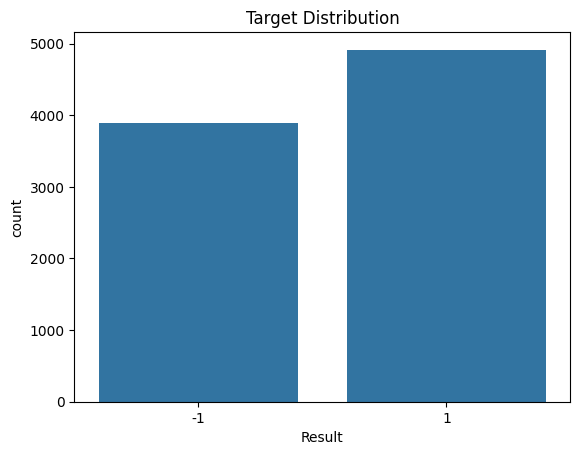

In [12]:
sns.countplot(
    x="Result",
    data=train_data
)

plt.title("Target Distribution")
plt.show()

##Correlation Heatmap

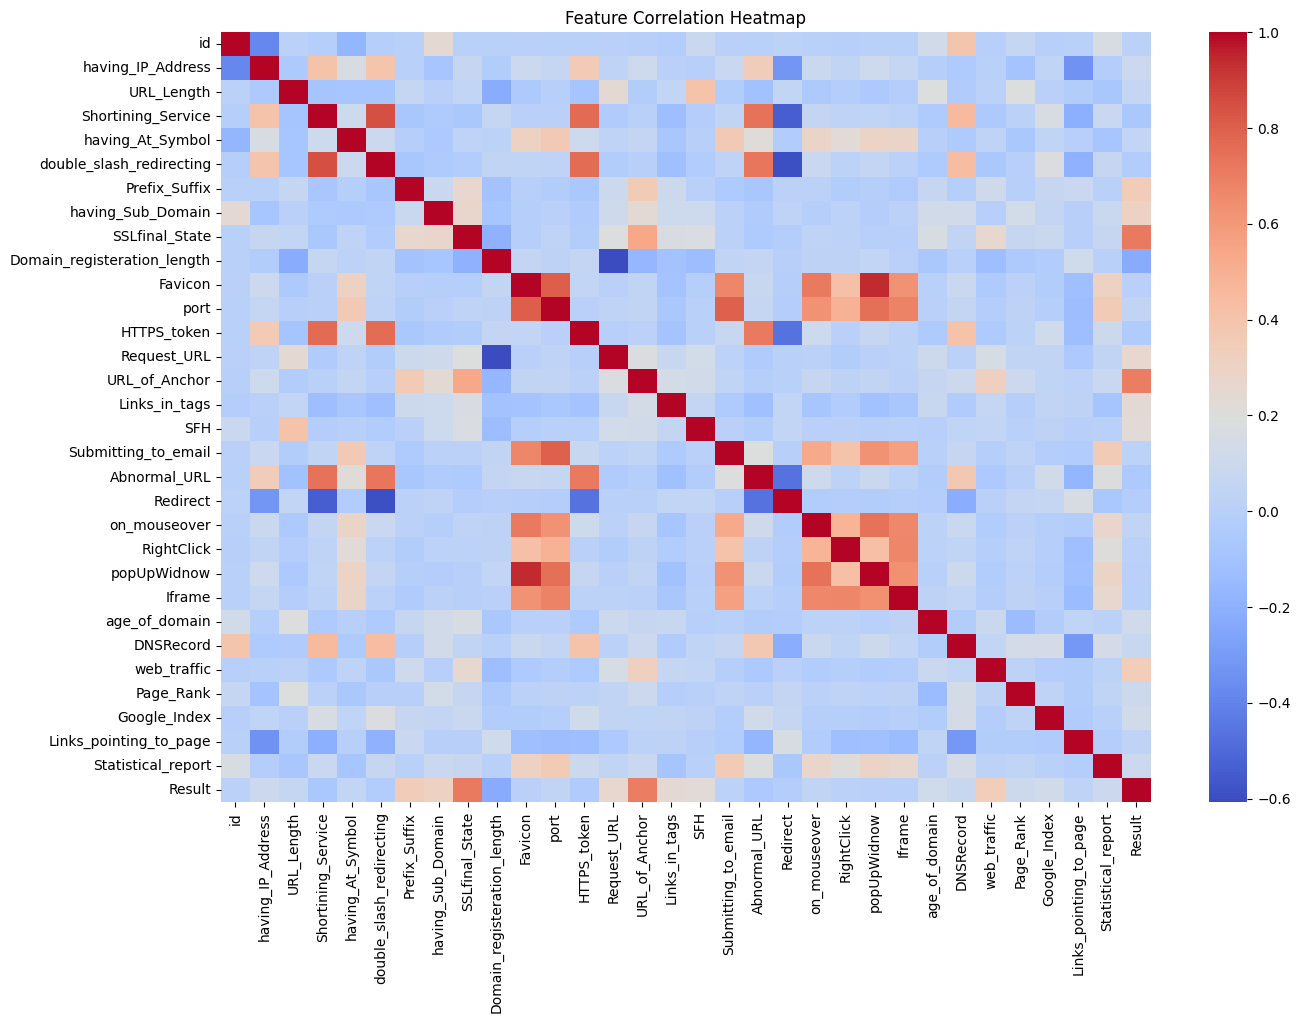

In [13]:
plt.figure(figsize=(15,10))

sns.heatmap(
    train_data.corr(),
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

##Feature and Target Separation

In [14]:
X = train_data.drop(
    ["id", "Result"],
    axis=1
)

y = train_data["Result"]

##Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##Train Decision Tree

In [17]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

##Predictions

In [18]:
y_pred = dt_model.predict(X_test)

##Accuracy

In [19]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9551645856980704


##Classification Report

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.96      0.94      0.95       779
           1       0.95      0.97      0.96       983

    accuracy                           0.96      1762
   macro avg       0.96      0.95      0.95      1762
weighted avg       0.96      0.96      0.96      1762



##Confusion Matrix

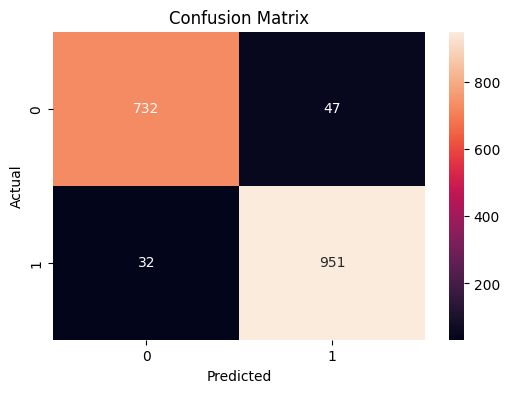

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

##Cross Validation

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    dt_model,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(scores)

print("\nAverage Accuracy:")
print(scores.mean())

Cross Validation Scores:
[0.95459705 0.959682   0.95229983 0.96592845 0.96252129]

Average Accuracy:
0.9590057243556152


##Decision Tree Visualization

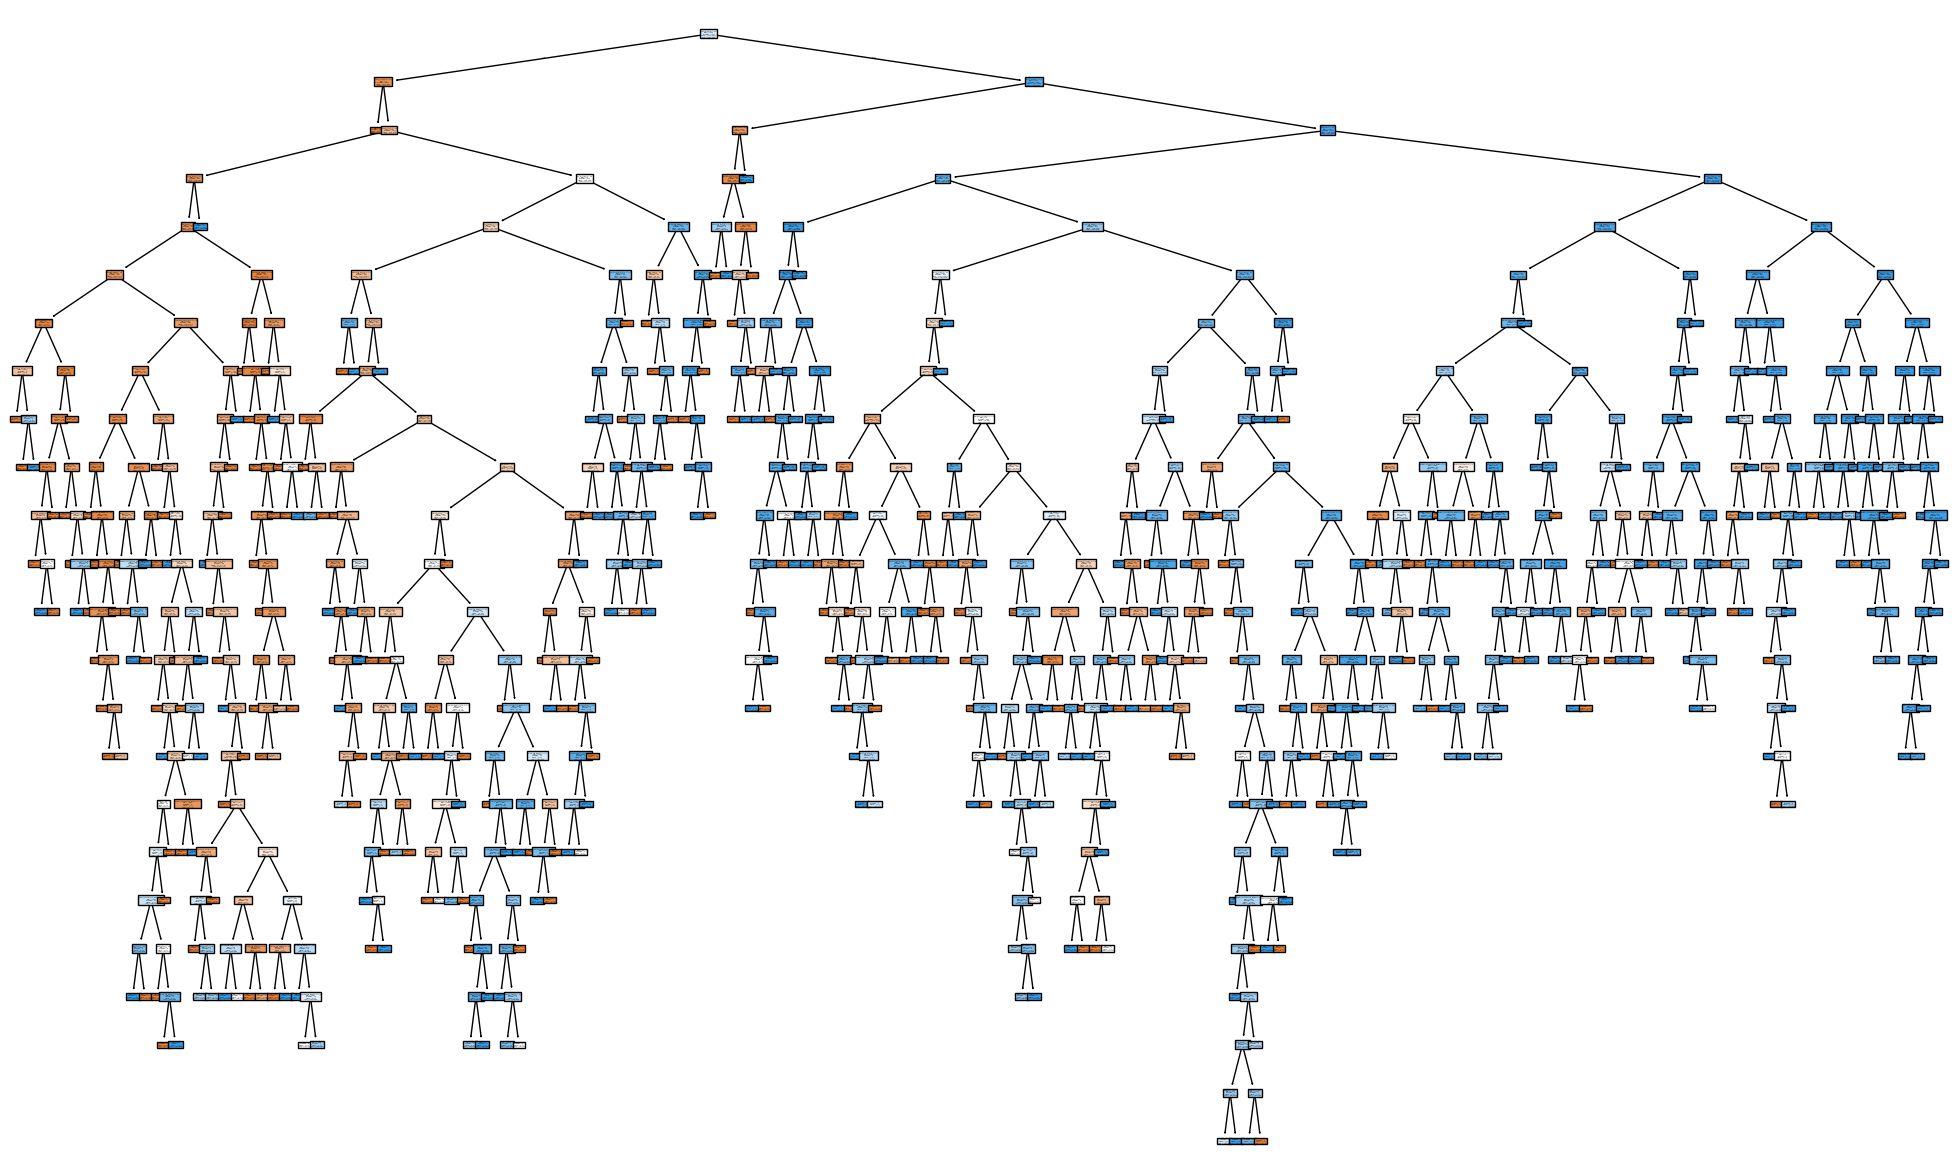

In [24]:
plt.figure(
    figsize=(25,15)
)

plot_tree(
    dt_model,
    filled=True,
    feature_names=X.columns,
    class_names=["Phishing", "Legitimate"]
)

plt.show()

##3 Layers of Decision Tree

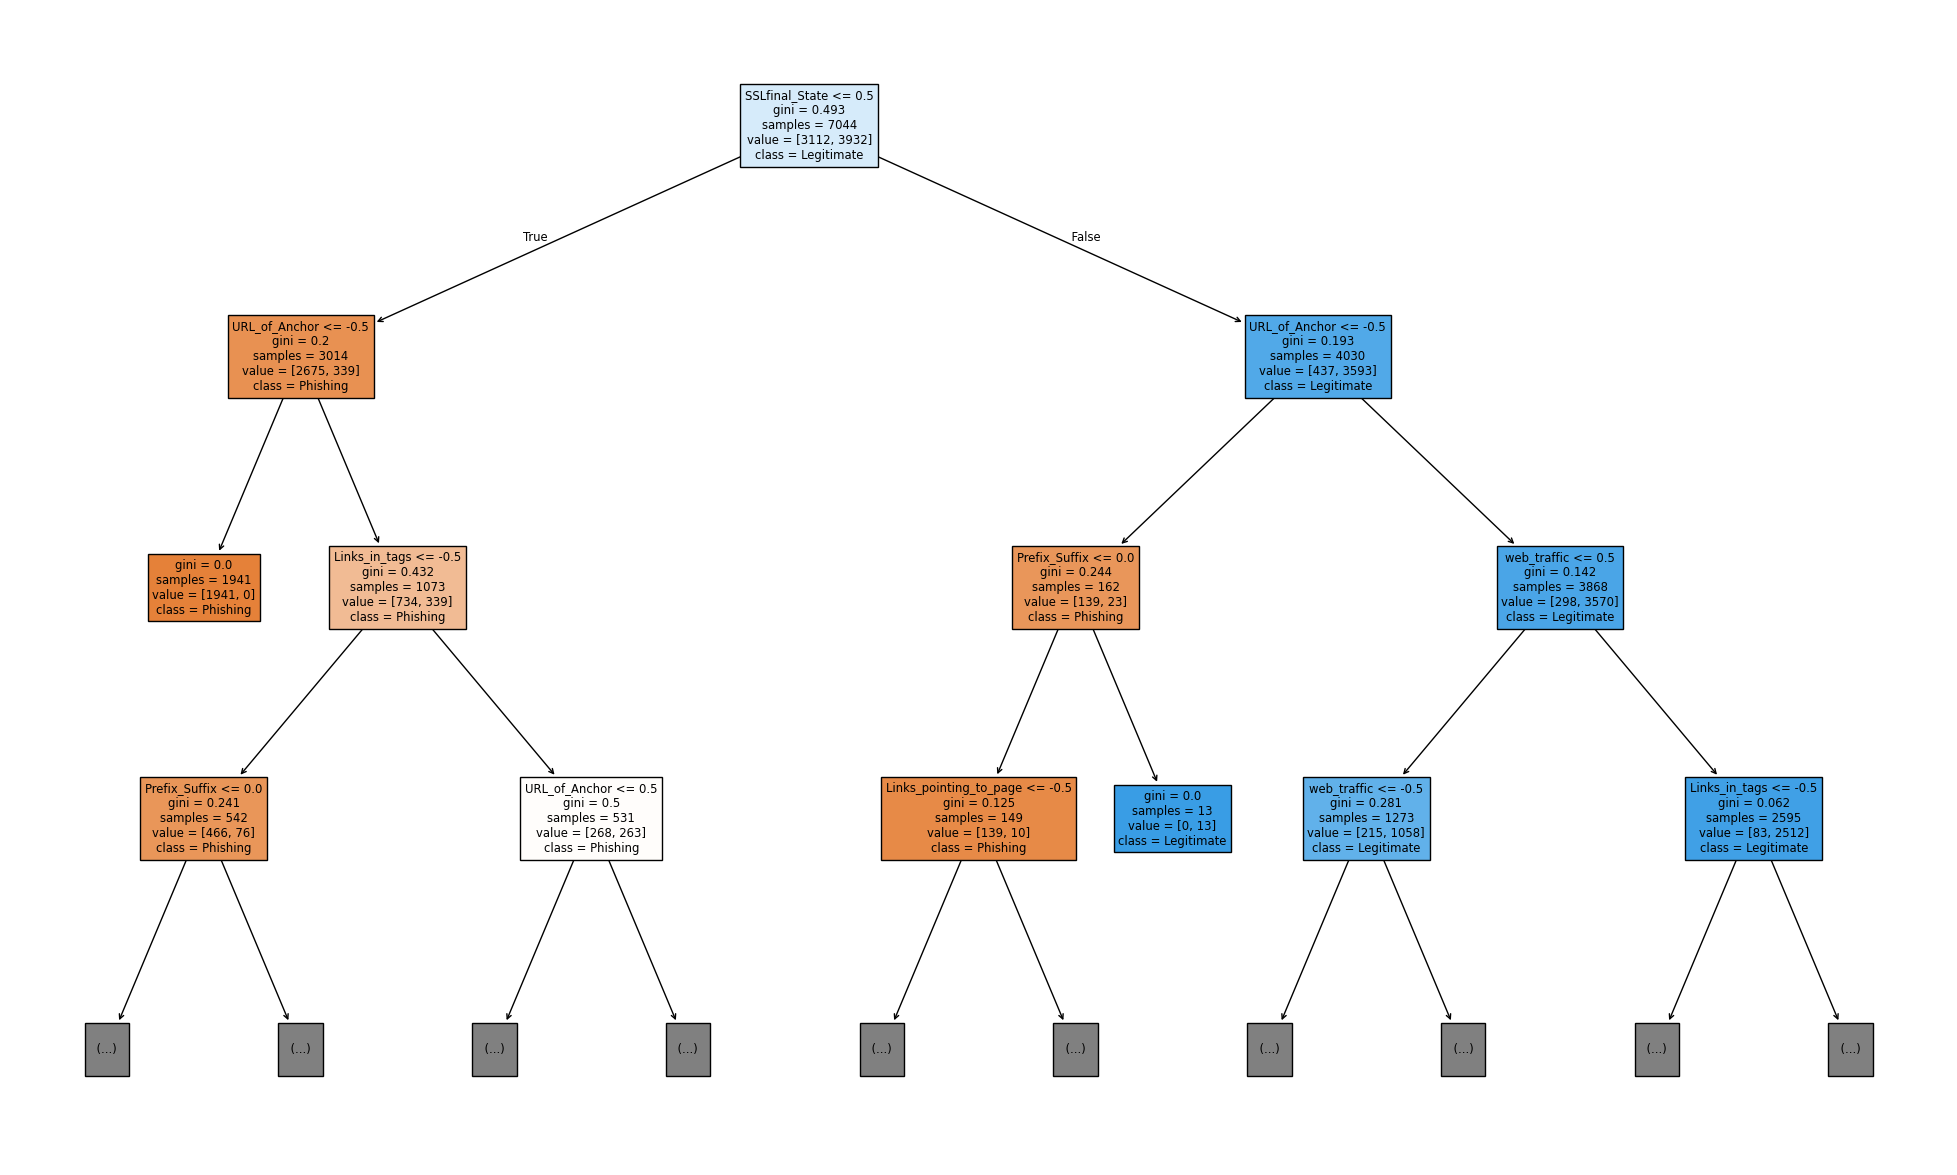

In [26]:
plt.figure(
    figsize=(25,15)
)

plot_tree(
    dt_model,
    filled=True,
    max_depth=3,
    feature_names=X.columns,
    class_names=["Phishing", "Legitimate"]
)

plt.show()

##Train Final Model

In [25]:
final_model = DecisionTreeClassifier(
    random_state=42
)

final_model.fit(
    X,
    y
)

DecisionTreeClassifier(random_state=42)

##Predict Test Dataset

In [27]:
X_test_final = test_data.drop(
    "id",
    axis=1
)

test_predictions = final_model.predict(
    X_test_final
)

In [30]:
final_fd = pd.DataFrame({
    "id": test_data["id"],
    "Result": test_predictions
})

final_fd.head()

,id,Result
0,4,-1
1,6,1
2,7,-1
3,9,1
4,10,-1
